In [ ]:
# ============================================================
# Step 1: Imports
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import keras

In [ ]:
import zipfile
import os

# Specify the path to your zip file
zip_file_path = '/content/IQ-OTH.zip'

# Specify the directory where you want to extract the files
extract_to_dir = '/content/unzip'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_to_dir, exist_ok=True)

# Open the zip file and extract its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_dir)

# Print a message indicating the extraction directory
print(f"Files extracted to {extract_to_dir}")

Files extracted to /content/unzip


In [ ]:
# ============================================================
# Step 1: Split dataset into train, validation, and test folders
# ============================================================

import os
import shutil
import random
from pathlib import Path

# -----------------------------
# Set your original dataset path
# -----------------------------
original_dataset_dir = r"/content/unzip/IQ-OTH"

# Output split dataset path
split_dataset_dir = r"/content/Split_CT_Dataset"

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

random_seed = 42
random.seed(random_seed)

# -----------------------------
# Create split folders
# -----------------------------
for split in ["train", "val", "test"]:
    split_path = os.path.join(split_dataset_dir, split)
    os.makedirs(split_path, exist_ok=True)

# -----------------------------
# Get class names
# -----------------------------
class_names = [
    folder for folder in os.listdir(original_dataset_dir)
    if os.path.isdir(os.path.join(original_dataset_dir, folder))
]

print("Detected classes:", class_names)

# -----------------------------
# Split each class separately
# -----------------------------
for class_name in class_names:

    class_source_dir = os.path.join(original_dataset_dir, class_name)

    images = [
        img for img in os.listdir(class_source_dir)
        if img.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]

    random.shuffle(images)

    total_images = len(images)
    train_count = int(total_images * train_ratio)
    val_count = int(total_images * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    print(f"\nClass: {class_name}")
    print(f"Total images: {total_images}")
    print(f"Train: {len(train_images)}")
    print(f"Validation: {len(val_images)}")
    print(f"Test: {len(test_images)}")

    for split_name, split_images in zip(
        ["train", "val", "test"],
        [train_images, val_images, test_images]
    ):

        class_split_dir = os.path.join(split_dataset_dir, split_name, class_name)
        os.makedirs(class_split_dir, exist_ok=True)

        for image_name in split_images:
            source_path = os.path.join(class_source_dir, image_name)
            destination_path = os.path.join(class_split_dir, image_name)

            if not os.path.exists(destination_path):
                shutil.copy2(source_path, destination_path)

print("\nDataset splitting completed successfully.")

Detected classes: ['Benign', 'Malignant']

Class: Benign
Total images: 120
Train: 84
Validation: 18
Test: 18

Class: Malignant
Total images: 350
Train: 244
Validation: 52
Test: 54

Dataset splitting completed successfully.


In [ ]:
# ============================================================
# Step 2: Verify dataset split count
# ============================================================

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET")

    split_path = os.path.join(split_dataset_dir, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len([
                img for img in os.listdir(class_path)
                if img.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
            ])

            print(f"{class_name}: {count}")


TRAIN SET
Benign: 84
Malignant: 244

VAL SET
Benign: 18
Malignant: 52

TEST SET
Benign: 18
Malignant: 54


In [ ]:
# ============================================================
# Step 2: Bilinear transform coefficient function
# ============================================================

def bilinear_first_order_coefficients(K=1.0, Tn=0.1, Td=0.2, Ts=1.0):
    """
    Converts analog first-order transfer function

        G(s) = K * (Tn*s + 1) / (Td*s + 1)

    into digital form using bilinear transform:

        s = (2/Ts) * (1 - z^-1) / (1 + z^-1)

    Result:

        H(z) = (b0 + b1*z^-1) / (1 + a1*z^-1)

    Returns
    -------
    b : numerator coefficients [b0, b1]
    a : denominator coefficients [1, a1]
    """

    numerator_0 = 1.0 + (2.0 * Tn / Ts)
    numerator_1 = 1.0 - (2.0 * Tn / Ts)

    denominator_0 = 1.0 + (2.0 * Td / Ts)
    denominator_1 = 1.0 - (2.0 * Td / Ts)

    b0 = K * numerator_0 / denominator_0
    b1 = K * numerator_1 / denominator_0
    a1 = denominator_1 / denominator_0

    b = np.array([b0, b1], dtype=np.float32)
    a = np.array([1.0, a1], dtype=np.float32)

    return b, a

In [ ]:
# ============================================================
# Step 3: Generate lag and lead coefficients from bilinear transform
# ============================================================

# Use the same parameters you used in your manuscript/experiments
K = 1.0
T1 = 0.1
T2 = 0.2
Ts = 1.0

# Lag: G_lag(s) = K * (T1*s + 1) / (T2*s + 1)
b_lag, a_lag = bilinear_first_order_coefficients(
    K=K,
    Tn=T1,
    Td=T2,
    Ts=Ts
)

# Lead: G_lead(s) = K * (T2*s + 1) / (T1*s + 1)
b_lead, a_lead = bilinear_first_order_coefficients(
    K=K,
    Tn=T2,
    Td=T1,
    Ts=Ts
)

print("========== Bilinear Transform Coefficients ==========")
print("Lag compensator:")
print("b_lag =", b_lag)
print("a_lag =", a_lag)

print("\nLead compensator:")
print("b_lead =", b_lead)
print("a_lead =", a_lead)

print("\nCNN convolution kernels used:")
print("K_lag  =", b_lag.reshape(1, 2))
print("K_lead =", b_lead.reshape(1, 2))

========== Bilinear Transform Coefficients ==========
Lag compensator:
b_lag = [0.85714287 0.5714286 ]
a_lag = [1.         0.42857143]

Lead compensator:
b_lead = [1.1666666 0.5      ]
a_lead = [1.        0.6666667]

CNN convolution kernels used:
K_lag  = [[0.85714287 0.5714286 ]]
K_lead = [[1.1666666 0.5      ]]


In [ ]:
# ============================================================
# Step 4: Bilinear-transform lag/lead convolution layer
# ============================================================

@keras.saving.register_keras_serializable()
class BilinearCompensationConvLayer(layers.Layer):
    """
    Fixed depthwise 1x2 convolution layer using bilinear-transform-derived
    coefficients.

    This layer applies the numerator coefficients [b0, b1] as a spatial
    convolution kernel over feature maps.

    Input shape:
        (batch, height, width, channels)

    Output shape:
        (batch, height, width, channels)
    """

    def __init__(self, kernel_coefficients, name_prefix="bilinear_comp", **kwargs):
        super().__init__(**kwargs)
        self.kernel_coefficients = np.array(kernel_coefficients, dtype=np.float32)
        self.name_prefix = name_prefix

    def build(self, input_shape):
        channels = int(input_shape[-1])

        # Kernel shape for depthwise_conv2d:
        # [kernel_height, kernel_width, input_channels, channel_multiplier]
        kernel = np.zeros((1, 2, channels, 1), dtype=np.float32)

        kernel[0, 0, :, 0] = self.kernel_coefficients[0]
        kernel[0, 1, :, 0] = self.kernel_coefficients[1]

        self.fixed_kernel = tf.constant(kernel, dtype=tf.float32)

    def call(self, inputs):
        # Pad width dimension so output size remains same
        padded_inputs = tf.pad(
            inputs,
            paddings=[[0, 0], [0, 0], [1, 0], [0, 0]],
            mode="REFLECT"
        )

        output = tf.nn.depthwise_conv2d(
            padded_inputs,
            self.fixed_kernel,
            strides=[1, 1, 1, 1],
            padding="VALID"
        )

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_coefficients": self.kernel_coefficients.tolist(),
            "name_prefix": self.name_prefix
        })
        return config

In [ ]:
# ============================================================
# Step 5: Build EfficientNetB3 with bilinear lag/lead compensation
# ============================================================

def build_efficientnet_b3_with_bilinear_lag_lead(
    input_shape=(300, 300, 3),
    K=1.0,
    T1=0.1,
    T2=0.2,
    Ts=1.0
):
    """
    EfficientNetB3 + bilinear-transform lag/lead compensation.

    The base EfficientNetB3 extracts deep feature maps.
    Lag and lead compensation are applied to the final convolutional feature map.
    Original, lag-compensated, and lead-compensated features are concatenated.
    """

    inputs = layers.Input(shape=input_shape)

    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    base_model.trainable = False

    x = base_model.output

    # Generate bilinear coefficients
    b_lag, a_lag = bilinear_first_order_coefficients(
        K=K,
        Tn=T1,
        Td=T2,
        Ts=Ts
    )

    b_lead, a_lead = bilinear_first_order_coefficients(
        K=K,
        Tn=T2,
        Td=T1,
        Ts=Ts
    )

    print("========== Model Bilinear Coefficients ==========")
    print("Lag H(z): b =", b_lag, ", a =", a_lag)
    print("Lead H(z): b =", b_lead, ", a =", a_lead)

    # Bilinear-transform-derived convolution kernels
    x_lag = BilinearCompensationConvLayer(
        kernel_coefficients=b_lag,
        name="bilinear_lag_conv"
    )(x)

    x_lead = BilinearCompensationConvLayer(
        kernel_coefficients=b_lead,
        name="bilinear_lead_conv"
    )(x)

    # Concatenate original + lag + lead features
    x = layers.Concatenate(name="concat_original_lag_lead")([x, x_lag, x_lead])

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

In [ ]:
# ============================================================
# Step 6: Create model
# ============================================================

input_shape = (300, 300, 3)

model, base_model = build_efficientnet_b3_with_bilinear_lag_lead(
    input_shape=input_shape,
    K=1.0,
    T1=0.1,
    T2=0.2,
    Ts=1.0
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.85714287 0.5714286 ] , a = [1.         0.42857143]
Lead H(z): b = [1.1666666 0.5      ] , a = [1.        0.6666667]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 10,788,144 (41.15 MB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Your already-split dataset folder
split_dataset_dir = r"/content/Split_CT_Dataset"

train_dir = os.path.join(split_dataset_dir, "train")
val_dir   = os.path.join(split_dataset_dir, "val")
test_dir  = os.path.join(split_dataset_dir, "test")

print("Train path:", train_dir)
print("Val path:", val_dir)
print("Test path:", test_dir)

print("Train exists:", os.path.exists(train_dir))
print("Val exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))

Train path: /content/Split_CT_Dataset/train
Val path: /content/Split_CT_Dataset/val
Test path: /content/Split_CT_Dataset/test
Train exists: True
Val exists: True
Test exists: True


In [ ]:
# ============================================================
# Create train, validation, and test generators
# ============================================================

IMG_SIZE = 300
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)
print("Number of training images:", train_data.samples)
print("Number of validation images:", val_data.samples)
print("Number of test images:", test_data.samples)

Found 328 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Class indices: {'Benign': 0, 'Malignant': 1}
Number of training images: 328
Number of validation images: 70
Number of test images: 72


In [ ]:
# ============================================================
# Step 7: Class weights
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9523809523809523), 1: np.float64(0.6721311475409836)}


In [ ]:
# ============================================================
# Step 8: Compile model
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
# ============================================================
# Step 9: Callbacks
# ============================================================

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        "best_bilinear_lag_lead_efficientnetB3.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# ============================================================
# Step 10: Initial training with frozen EfficientNetB3
# ============================================================

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5236 - auc: 0.4571 - loss: 0.7173 - precision: 0.7199 - recall: 0.5758
Epoch 1: val_accuracy improved from None to 0.25714, saving model to best_bilinear_lag_lead_efficientnetB3.keras

Epoch 1: finished saving model to best_bilinear_lag_lead_efficientnetB3.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.4817 - auc: 0.4604 - loss: 0.7115 - precision: 0.7256 - recall: 0.4877 - val_accuracy: 0.2571 - val_auc: 0.4936 - val_loss: 0.7001 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.4962 - auc: 0.4710 - loss: 0.6844 - precision: 0.7492 - recall: 0.5351
Epoch 2: val_accuracy improved from 0.25714 to 0.58571, saving model to best_bilinear_lag_lead_efficientnetB3.keras

Epoch 2: finished saving model to best_bilinear_lag_lead_efficientnetB3.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 371ms/step - accuracy: 0.5610 - auc: 0.4426 - 

In [ ]:
# ============================================================
# Step 11: Fine-tuning
# ============================================================

base_model.trainable = True

# Freeze lower layers, fine-tune only top layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    class_weight=class_weights,
    callbacks=callbacks
)

model.save("final_bilinear_lag_lead_efficientnetB3.keras")

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4834 - auc: 0.5421 - loss: 0.6789 - precision: 0.8007 - recall: 0.4449
Epoch 1: val_accuracy did not improve from 0.81429
21/21 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.5030 - auc: 0.5466 - loss: 0.7155 - precision: 0.7755 - recall: 0.4672 - val_accuracy: 0.7429 - val_auc: 0.6811 - val_loss: 0.6767 - val_precision: 0.7429 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5083 - auc: 0.4773 - loss: 0.7634 - precision: 0.7105 - recall: 0.5258
Epoch 2: val_accuracy did not improve from 0.81429
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 322ms/step - accuracy: 0.5335 - auc: 0.5201 - loss: 0.7105 - precision: 0.7725 - recall: 0.5287 - val_accuracy: 0.7429 - val_auc: 0.6976 - val_loss: 0.6599 - val_precision: 0.7429 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.4648 - auc: 0.4906 - loss: 0.7366 - preci

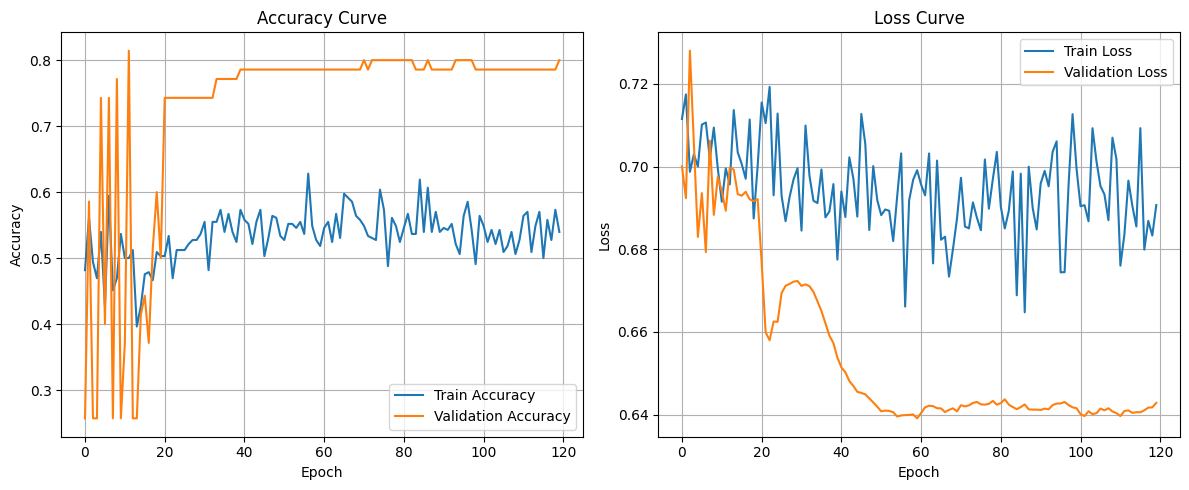

In [ ]:
# ============================================================
# Step 12: Plot training curves
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history["accuracy"] + history2.history["accuracy"], label="Train Accuracy")
plt.plot(history1.history["val_accuracy"] + history2.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history1.history["loss"] + history2.history["loss"], label="Train Loss")
plt.plot(history1.history["val_loss"] + history2.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Testing and performance metric imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import seaborn as sns

In [ ]:
# ============================================================
# Predict on test data
# ============================================================

test_data.reset()

y_true = test_data.classes

y_prob = model.predict(test_data, verbose=1)
y_prob = y_prob.ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("Total test images:", len(y_true))
print("Prediction shape:", y_prob.shape)
print("True labels shape:", y_true.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step
Total test images: 72
Prediction shape: (72,)
True labels shape: (72,)


In [ ]:
# ============================================================
# Class label mapping
# ============================================================

print("Class indices:", test_data.class_indices)

class_names = list(test_data.class_indices.keys())
print("Class names:", class_names)

Class indices: {'Benign': 0, 'Malignant': 1}
Class names: ['Benign', 'Malignant']


In [ ]:
# ============================================================
# Performance metrics
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
sensitivity = recall_score(y_true, y_pred, zero_division=0)   # Recall / Sensitivity
f1 = f1_score(y_true, y_pred, zero_division=0)

try:
    auc = roc_auc_score(y_true, y_prob)
except:
    auc = np.nan

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
npv = tn / (tn + fn) if (tn + fn) != 0 else 0

print("========== Test Performance Metrics ==========")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"NPV          : {npv:.4f}")

print("\n========== Confusion Matrix Values ==========")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

========== Test Performance Metrics ==========
Accuracy     : 0.8056
Precision    : 0.7941
Sensitivity  : 1.0000
Specificity  : 0.2222
F1-score     : 0.8852
AUC          : 0.7932
NPV          : 1.0000

========== Confusion Matrix Values ==========
TN: 4
FP: 14
FN: 0
TP: 54


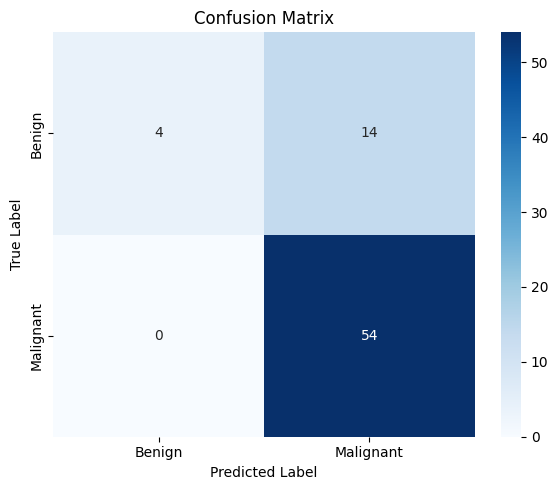

In [ ]:
# ============================================================
# Confusion matrix plot
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

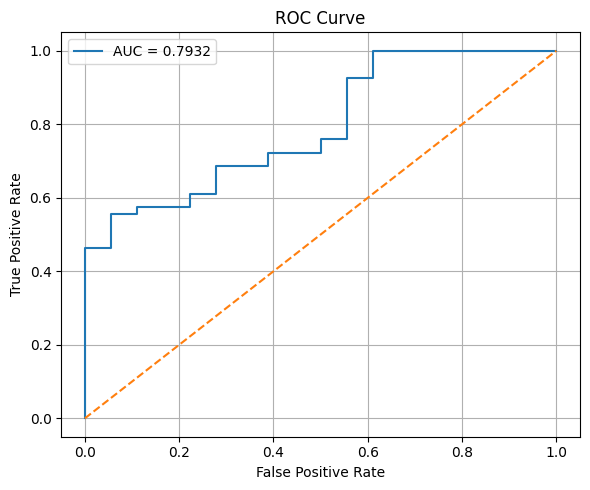

In [ ]:
# ============================================================
# ROC curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# coefficient
# ============================================================

def print_bilinear_table(K=1.0, T1=0.1, T2=0.2, Ts=1.0):
    b_lag, a_lag = bilinear_first_order_coefficients(K=K, Tn=T1, Td=T2, Ts=Ts)
    b_lead, a_lead = bilinear_first_order_coefficients(K=K, Tn=T2, Td=T1, Ts=Ts)

    print("Parameter settings:")
    print(f"K  = {K}")
    print(f"T1 = {T1}")
    print(f"T2 = {T2}")
    print(f"Ts = {Ts}")
    print()

    print("Digital lag compensator:")
    print(f"H_lag(z) = ({b_lag[0]:.6f} + {b_lag[1]:.6f} z^-1) / (1 + {a_lag[1]:.6f} z^-1)")
    print(f"K_lag kernel size: 1 x 2")
    print(f"K_lag coefficients: [{b_lag[0]:.6f}, {b_lag[1]:.6f}]")
    print()

    print("Digital lead compensator:")
    print(f"H_lead(z) = ({b_lead[0]:.6f} + {b_lead[1]:.6f} z^-1) / (1 + {a_lead[1]:.6f} z^-1)")
    print(f"K_lead kernel size: 1 x 2")
    print(f"K_lead coefficients: [{b_lead[0]:.6f}, {b_lead[1]:.6f}]")

print_bilinear_table(K=1.0, T1=0.1, T2=0.2, Ts=1.0)

Parameter settings:
K  = 1.0
T1 = 0.1
T2 = 0.2
Ts = 1.0

Digital lag compensator:
H_lag(z) = (0.857143 + 0.571429 z^-1) / (1 + 0.428571 z^-1)
K_lag kernel size: 1 x 2
K_lag coefficients: [0.857143, 0.571429]

Digital lead compensator:
H_lead(z) = (1.166667 + 0.500000 z^-1) / (1 + 0.666667 z^-1)
K_lead kernel size: 1 x 2
K_lead coefficients: [1.166667, 0.500000]


In [ ]:
# ============================================================
# Sensitivity Analysis Imports
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
# ============================================================
# Evaluation function
# ============================================================

def evaluate_model_metrics(model, test_data):
    """
    Evaluates the trained model on test data.
    Returns accuracy, precision, sensitivity/recall, F1-score, and AUC.
    """

    test_data.reset()

    y_true = test_data.classes
    y_prob = model.predict(test_data, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    return accuracy, precision, sensitivity, f1, auc

In [ ]:
# ============================================================
# Sensitivity analysis for K
# ============================================================

K_values = [0.5, 0.75, 1.0, 1.25, 1.5]

T1_fixed = 0.1
T2_fixed = 0.2
Ts_fixed = 1.0

sensitivity_results_K = []

for K_value in K_values:

    print("\n====================================")
    print(f"Testing K = {K_value}")
    print("====================================")

    temp_model, temp_base_model = build_efficientnet_b3_with_bilinear_lag_lead(
        input_shape=(300, 300, 3),
        K=K_value,
        T1=T1_fixed,
        T2=T2_fixed,
        Ts=Ts_fixed
    )

    temp_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history_temp = temp_model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        class_weight=class_weights,
        verbose=1
    )

    accuracy, precision, sensitivity, f1, auc = evaluate_model_metrics(temp_model, test_data)

    sensitivity_results_K.append({
        "Parameter": "K",
        "Value": K_value,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "F1_score": f1,
        "AUC": auc
    })

sensitivity_K_df = pd.DataFrame(sensitivity_results_K)
sensitivity_K_df


Testing K = 0.5
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.42857143 0.2857143 ] , a = [1.         0.42857143]
Lead H(z): b = [0.5833333 0.25     ] , a = [1.        0.6666667]
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.3476 - loss: 0.6914 - val_accuracy: 0.2571 - val_loss: 0.6986
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 319ms/step - accuracy: 0.6524 - loss: 0.7021 - val_accuracy: 0.7429 - val_loss: 0.6579
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.5000 - loss: 0.7004 - val_accuracy: 0.2571 - val_loss: 0.7008
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.4268 - loss: 0.6999 - val_accuracy: 0.2571 - val_loss: 0.7047
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.5701 - loss: 0.6952 - val_accuracy: 0.7429 - val_loss: 0.6766
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

Testing K = 0.75
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.64285713 0.42857143] , a = [1.         0.4285

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

Testing K = 1.0
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.85714287 0.5714286 ] , a = [1.         0.42857143]
Lead H(z): b = [1.1666666 0.5      ] , a = [1.        0.6666667]
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.5366 - loss: 0.7115 - val_accuracy: 0.7429 - val_loss: 0.6615
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.3963 - loss: 0.7082 - val_accuracy: 0.2571 - val_loss: 0.7266
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - accuracy: 0.5000 - loss: 0.6969 - val_accuracy: 0.7429 - val_loss: 0.6819
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 322ms/step - accuracy: 0.5427 - loss: 0.6996 - val_accuracy: 0.7429 - val_loss: 0.6876
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - accuracy: 0.5244 - loss: 0.6985 - val_accuracy: 0.2571 - val_loss: 0.7177
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step

Testing K = 1.25
========== Model Bilinear Coefficients ==========
Lag H(z): b = [1.0714285 

,Parameter,Value,Accuracy,Precision,Sensitivity,F1_score,AUC
0,K,0.50,0.750000,0.750000,1.0,0.857143,0.613169
1,K,0.75,0.250000,0.000000,0.0,0.000000,0.367284
2,K,1.00,0.250000,0.000000,0.0,0.000000,0.589506
3,K,1.25,0.541667,0.818182,0.5,0.620690,0.587449
4,K,1.50,0.750000,0.750000,1.0,0.857143,0.600823


In [ ]:
# ============================================================
# Sensitivity analysis for T1
# ============================================================

T1_values = [0.05, 0.075, 0.1, 0.125, 0.15]

K_fixed = 1.0
T2_fixed = 0.2
Ts_fixed = 1.0

sensitivity_results_T1 = []

for T1_value in T1_values:

    print("\n====================================")
    print(f"Testing T1 = {T1_value}")
    print("====================================")

    temp_model, temp_base_model = build_efficientnet_b3_with_bilinear_lag_lead(
        input_shape=(300, 300, 3),
        K=K_fixed,
        T1=T1_value,
        T2=T2_fixed,
        Ts=Ts_fixed
    )

    temp_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history_temp = temp_model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        class_weight=class_weights,
        verbose=1
    )

    accuracy, precision, sensitivity, f1, auc = evaluate_model_metrics(temp_model, test_data)

    sensitivity_results_T1.append({
        "Parameter": "T1",
        "Value": T1_value,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "F1_score": f1,
        "AUC": auc
    })

sensitivity_T1_df = pd.DataFrame(sensitivity_results_T1)
sensitivity_T1_df


Testing T1 = 0.05
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.78571427 0.64285713] , a = [1.         0.42857143]
Lead H(z): b = [1.2727273  0.54545456] , a = [1.        0.8181818]
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.3872 - loss: 0.7145 - val_accuracy: 0.7429 - val_loss: 0.6634
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 329ms/step - accuracy: 0.6098 - loss: 0.7007 - val_accuracy: 0.7429 - val_loss: 0.6819
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 326ms/step - accuracy: 0.5061 - loss: 0.7054 - val_accuracy: 0.2571 - val_loss: 0.7250
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 323ms/step - accuracy: 0.4177 - loss: 0.6963 - val_accuracy: 0.2571 - val_loss: 0.7200
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 329ms/step - accuracy: 0.4726 - loss: 0.7215 - val_accuracy: 0.7429 - val_loss: 0.6741
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

Testing T1 = 0.075
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.8214286  0.60714287] , a = [1.         

,Parameter,Value,Accuracy,Precision,Sensitivity,F1_score,AUC
0,T1,0.050,0.750000,0.750000,1.0,0.857143,0.502058
1,T1,0.075,0.777778,0.771429,1.0,0.870968,0.685185
2,T1,0.100,0.750000,0.750000,1.0,0.857143,0.594650
3,T1,0.125,0.777778,0.771429,1.0,0.870968,0.597737
4,T1,0.150,0.750000,0.750000,1.0,0.857143,0.725309


In [ ]:
# ============================================================
# Sensitivity analysis for T2
# ============================================================

T2_values = [0.1, 0.15, 0.2, 0.25, 0.3]

K_fixed = 1.0
T1_fixed = 0.1
Ts_fixed = 1.0

sensitivity_results_T2 = []

for T2_value in T2_values:

    print("\n====================================")
    print(f"Testing T2 = {T2_value}")
    print("====================================")

    temp_model, temp_base_model = build_efficientnet_b3_with_bilinear_lag_lead(
        input_shape=(300, 300, 3),
        K=K_fixed,
        T1=T1_fixed,
        T2=T2_value,
        Ts=Ts_fixed
    )

    temp_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history_temp = temp_model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        class_weight=class_weights,
        verbose=1
    )

    accuracy, precision, sensitivity, f1, auc = evaluate_model_metrics(temp_model, test_data)

    sensitivity_results_T2.append({
        "Parameter": "T2",
        "Value": T2_value,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "F1_score": f1,
        "AUC": auc
    })

sensitivity_T2_df = pd.DataFrame(sensitivity_results_T2)
sensitivity_T2_df


Testing T2 = 0.1
========== Model Bilinear Coefficients ==========
Lag H(z): b = [1.        0.6666667] , a = [1.        0.6666667]
Lead H(z): b = [1.        0.6666667] , a = [1.        0.6666667]
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6280 - loss: 0.7066 - val_accuracy: 0.2571 - val_loss: 0.7085
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - accuracy: 0.3476 - loss: 0.7085 - val_accuracy: 0.2571 - val_loss: 0.7323
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.5671 - loss: 0.6911 - val_accuracy: 0.7429 - val_loss: 0.6656
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 324ms/step - accuracy: 0.5518 - loss: 0.6867 - val_accuracy: 0.2571 - val_loss: 0.7098
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.3994 - loss: 0.7197 - val_accuracy: 0.7714 - val_loss: 0.6857
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

Testing T2 = 0.15
========== Model Bilinear Coefficients ==========
Lag H(z): b = [0.9230769  0.61538464] , a = [1.         0.538461

,Parameter,Value,Accuracy,Precision,Sensitivity,F1_score,AUC
0,T2,0.10,0.777778,0.771429,1.000000,0.870968,0.608025
1,T2,0.15,0.250000,0.000000,0.000000,0.000000,0.735597
2,T2,0.20,0.458333,0.741935,0.425926,0.541176,0.539095
3,T2,0.25,0.250000,0.000000,0.000000,0.000000,0.681070
4,T2,0.30,0.458333,0.941176,0.296296,0.450704,0.530864


In [ ]:
# ============================================================
# Combine sensitivity analysis results
# ============================================================

sensitivity_all_df = pd.concat(
    [sensitivity_K_df, sensitivity_T1_df, sensitivity_T2_df],
    axis=0,
    ignore_index=True
)

sensitivity_all_df

,Parameter,Value,Accuracy,Precision,Sensitivity,F1_score,AUC
0,K,0.500,0.750000,0.750000,1.000000,0.857143,0.613169
1,K,0.750,0.250000,0.000000,0.000000,0.000000,0.367284
2,K,1.000,0.250000,0.000000,0.000000,0.000000,0.589506
3,K,1.250,0.541667,0.818182,0.500000,0.620690,0.587449
4,K,1.500,0.750000,0.750000,1.000000,0.857143,0.600823
5,T1,0.050,0.750000,0.750000,1.000000,0.857143,0.502058
6,T1,0.075,0.777778,0.771429,1.000000,0.870968,0.685185
7,T1,0.100,0.750000,0.750000,1.000000,0.857143,0.594650
8,T1,0.125,0.777778,0.771429,1.000000,0.870968,0.597737
9,T1,0.150,0.750000,0.750000,1.000000,0.857143,0.725309


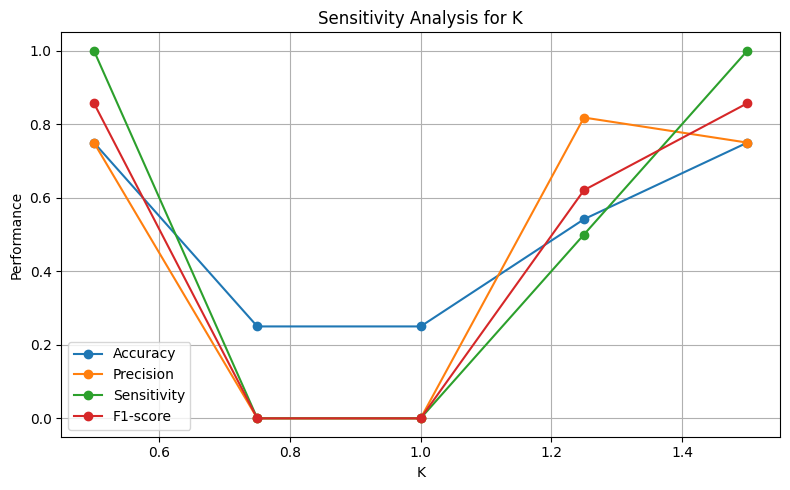

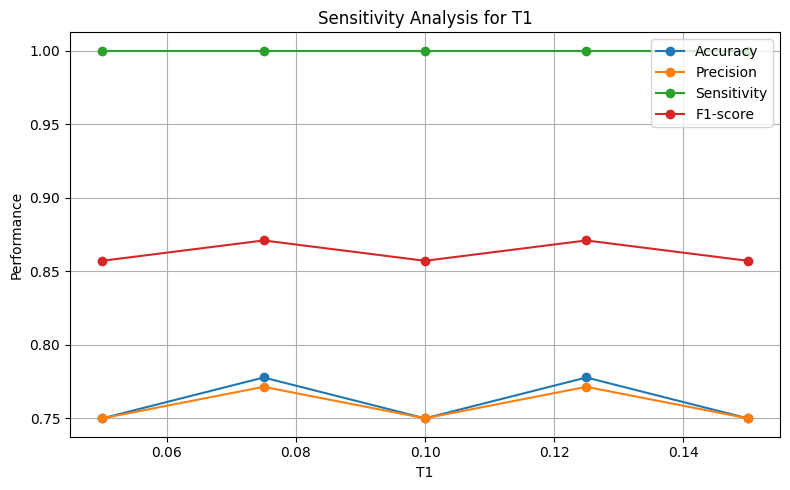

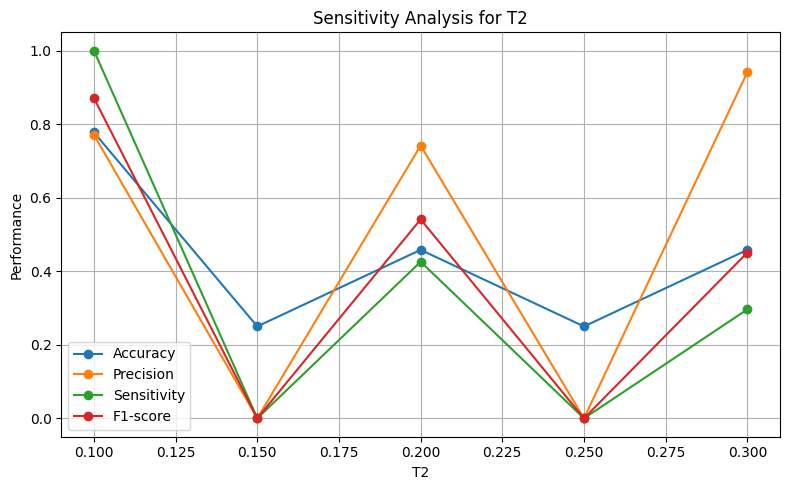

In [ ]:
# ============================================================
# Plot sensitivity analysis
# ============================================================

for parameter in ["K", "T1", "T2"]:

    temp_df = sensitivity_all_df[sensitivity_all_df["Parameter"] == parameter]

    plt.figure(figsize=(8, 5))
    plt.plot(temp_df["Value"], temp_df["Accuracy"], marker="o", label="Accuracy")
    plt.plot(temp_df["Value"], temp_df["Precision"], marker="o", label="Precision")
    plt.plot(temp_df["Value"], temp_df["Sensitivity"], marker="o", label="Sensitivity")
    plt.plot(temp_df["Value"], temp_df["F1_score"], marker="o", label="F1-score")

    plt.xlabel(parameter)
    plt.ylabel("Performance")
    plt.title(f"Sensitivity Analysis for {parameter}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"sensitivity_analysis_{parameter}.png", dpi=300)
    plt.show()

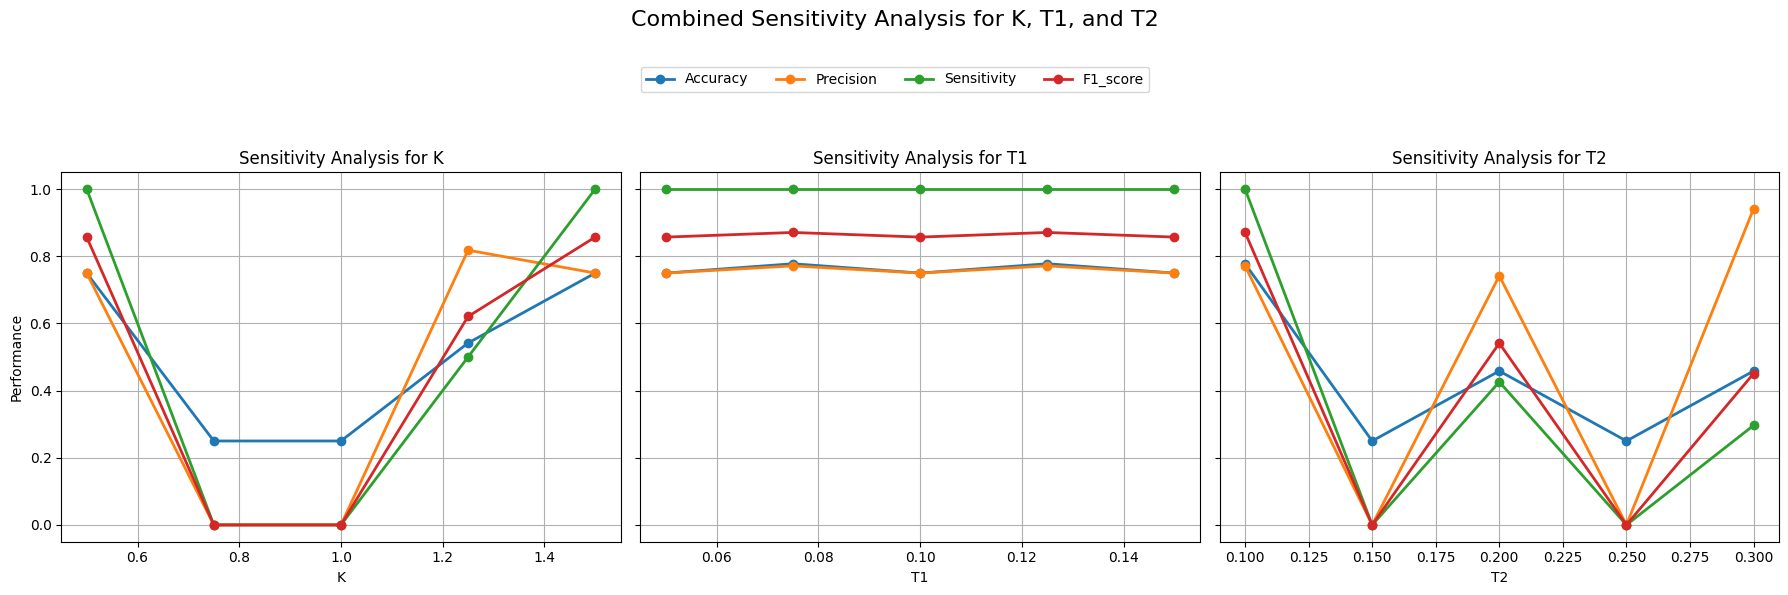

In [ ]:
# ============================================================
# Combined sensitivity plot: K, T1, T2 in one figure
# ============================================================

import matplotlib.pyplot as plt

parameters = ["K", "T1", "T2"]
metrics = ["Accuracy", "Precision", "Sensitivity", "F1_score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, parameter in zip(axes, parameters):

    temp_df = sensitivity_all_df[
        sensitivity_all_df["Parameter"] == parameter
    ].sort_values("Value")

    for metric in metrics:
        ax.plot(
            temp_df["Value"],
            temp_df[metric],
            marker="o",
            linewidth=2,
            label=metric
        )

    ax.set_xlabel(parameter)
    ax.set_title(f"Sensitivity Analysis for {parameter}")
    ax.grid(True)

axes[0].set_ylabel("Performance")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.08)
)

plt.suptitle(
    "Combined Sensitivity Analysis for K, T1, and T2",
    y=1.18,
    fontsize=16
)

plt.tight_layout()
plt.savefig("combined_sensitivity_analysis_K_T1_T2.png", dpi=300, bbox_inches="tight")
plt.show()

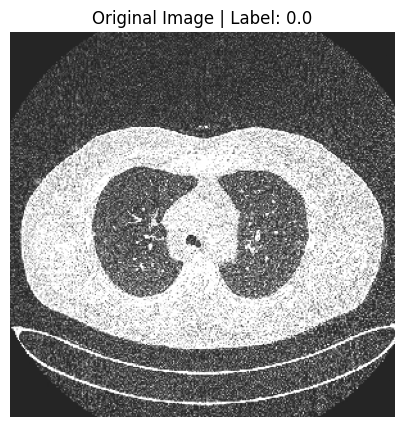

In [ ]:
# ============================================================
# Get one image from test data
# ============================================================

test_data.reset()

sample_images, sample_labels = next(test_data)

sample_image = sample_images[0]
sample_label = sample_labels[0]

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.title(f"Original Image | Label: {sample_label}")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# Feature map visualization
# ============================================================

def show_feature_maps(model, image, layer_name, max_maps=16):

    feature_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )

    image_batch = np.expand_dims(image, axis=0)

    feature_maps = feature_model.predict(image_batch)

    print("Feature map shape:", feature_maps.shape)

    num_maps = min(max_maps, feature_maps.shape[-1])

    plt.figure(figsize=(12, 12))

    for i in range(num_maps):
        plt.subplot(4, 4, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Map {i+1}")

    plt.suptitle(f"Feature Maps from Layer: {layer_name}")
    plt.tight_layout()
    plt.savefig(f"feature_maps_{layer_name}.png", dpi=300)
    plt.show()

In [ ]:
# ============================================================
# Print model layer names
# ============================================================

for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output_shape if hasattr(layer, "output_shape") else "")

0 input_layer 
1 rescaling 
2 normalization 
3 rescaling_1 
4 stem_conv_pad 
5 stem_conv 
6 stem_bn 
7 stem_activation 
8 block1a_dwconv 
9 block1a_bn 
10 block1a_activation 
11 block1a_se_squeeze 
12 block1a_se_reshape 
13 block1a_se_reduce 
14 block1a_se_expand 
15 block1a_se_excite 
16 block1a_project_conv 
17 block1a_project_bn 
18 block1b_dwconv 
19 block1b_bn 
20 block1b_activation 
21 block1b_se_squeeze 
22 block1b_se_reshape 
23 block1b_se_reduce 
24 block1b_se_expand 
25 block1b_se_excite 
26 block1b_project_conv 
27 block1b_project_bn 
28 block1b_drop 
29 block1b_add 
30 block2a_expand_conv 
31 block2a_expand_bn 
32 block2a_expand_activation 
33 block2a_dwconv_pad 
34 block2a_dwconv 
35 block2a_bn 
36 block2a_activation 
37 block2a_se_squeeze 
38 block2a_se_reshape 
39 block2a_se_reduce 
40 block2a_se_expand 
41 block2a_se_excite 
42 block2a_project_conv 
43 block2a_project_bn 
44 block2b_expand_conv 
45 block2b_expand_bn 
46 block2b_expand_activation 
47 block2b_dwconv 
48 b

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Feature map shape: (1, 10, 10, 1536)


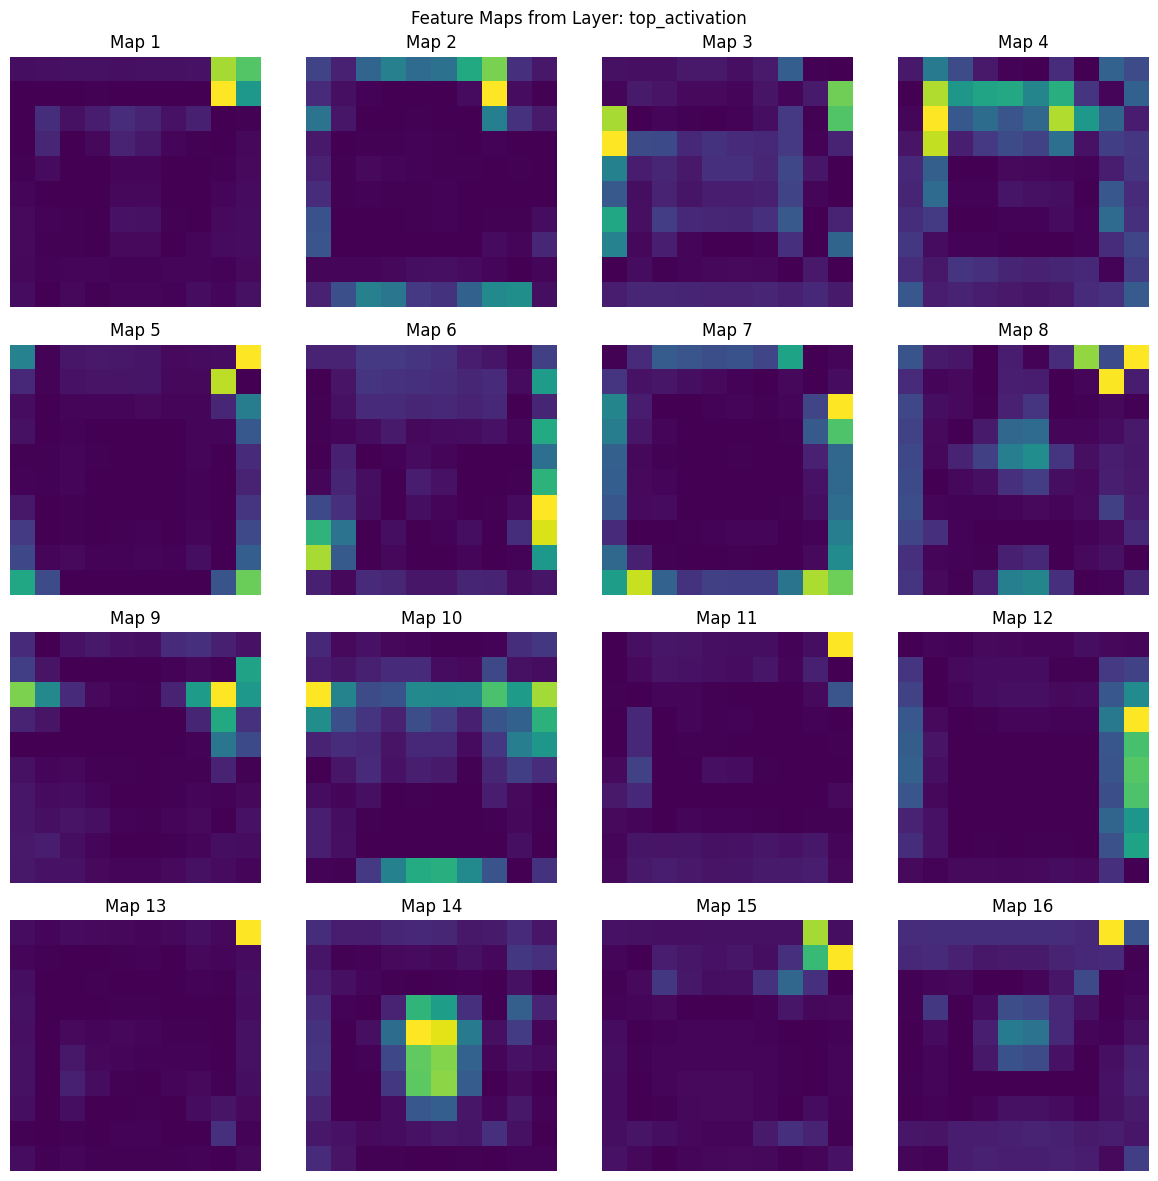

In [ ]:
show_feature_maps(
    model=model,
    image=sample_image,
    layer_name="top_activation",
    max_maps=16
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Feature map shape: (1, 10, 10, 1536)


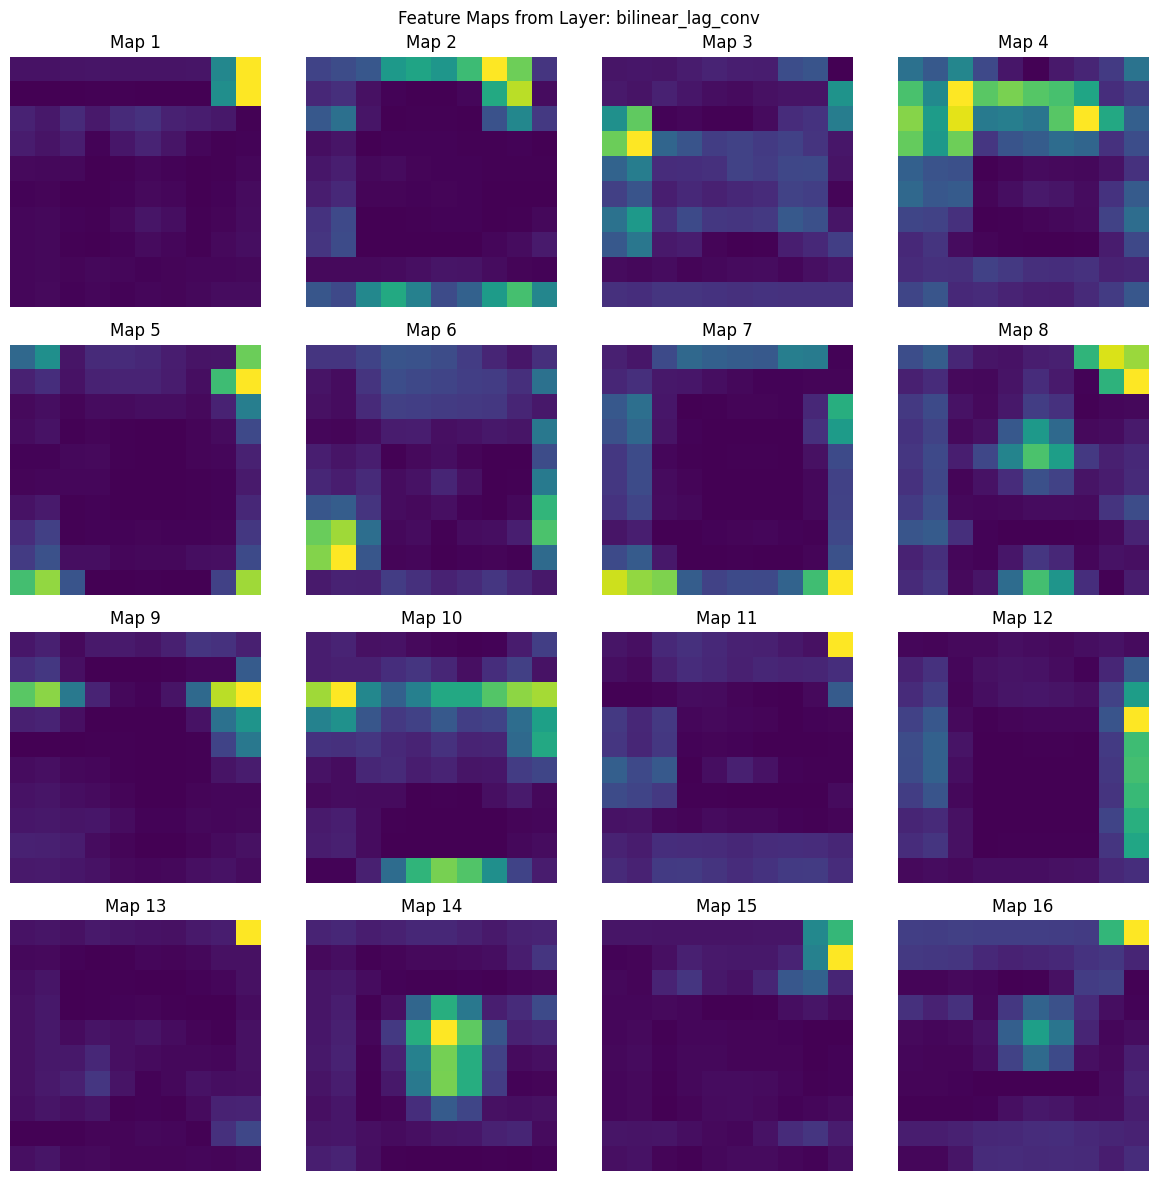

In [ ]:
show_feature_maps(
    model=model,
    image=sample_image,
    layer_name="bilinear_lag_conv",
    max_maps=16
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Feature map shape: (1, 10, 10, 1536)


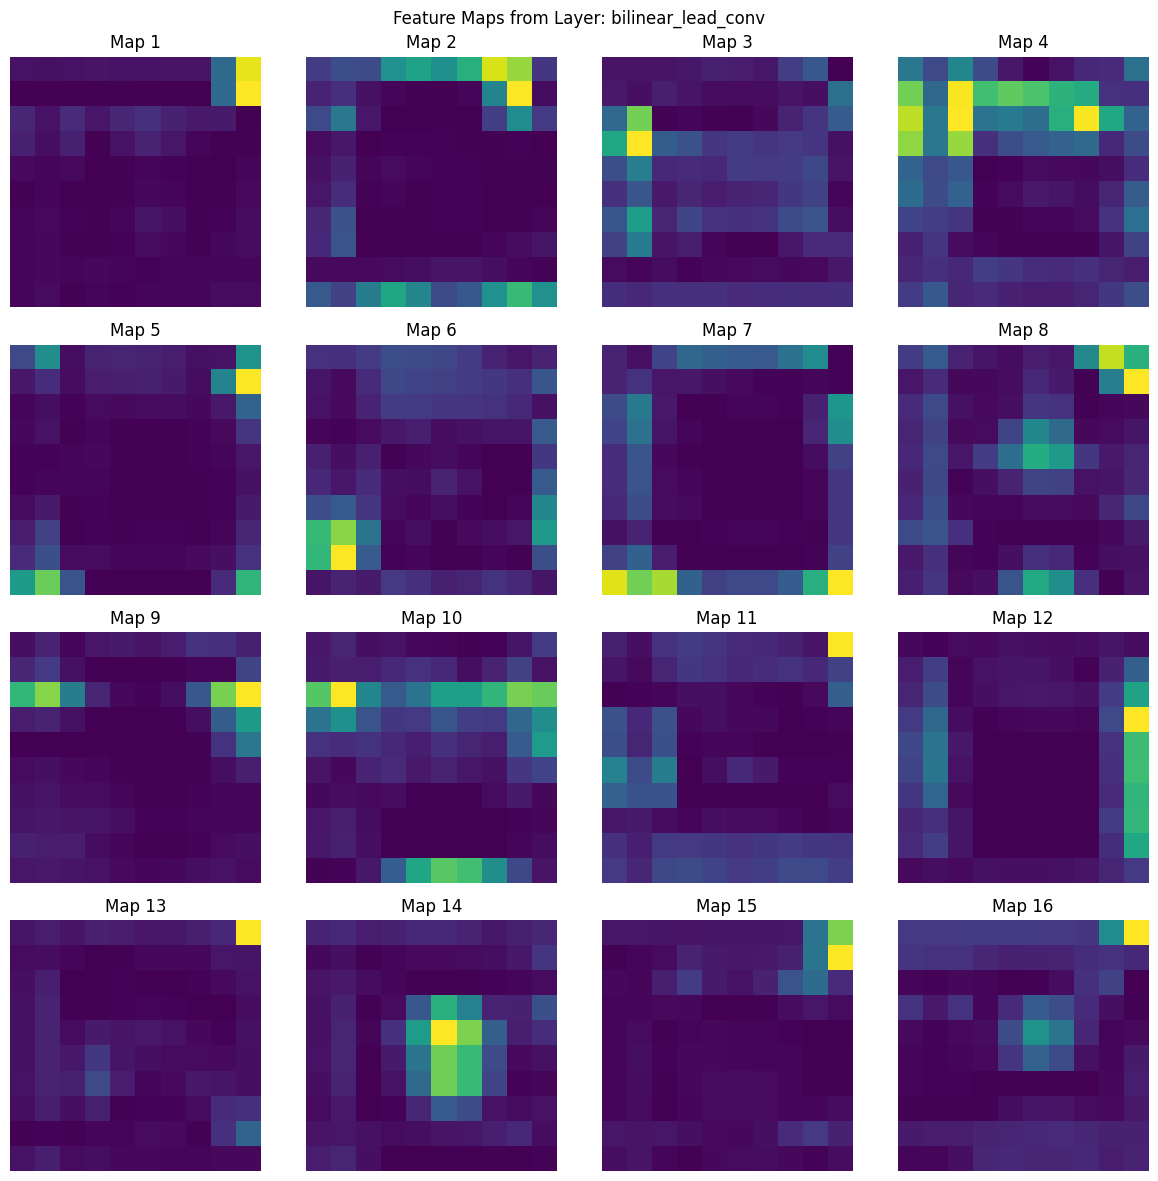

In [ ]:
show_feature_maps(
    model=model,
    image=sample_image,
    layer_name="bilinear_lead_conv",
    max_maps=16
)

In [ ]:
# ============================================================
# Grad-CAM function for binary classification
# ============================================================

import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates Grad-CAM heatmap for a binary classification model.
    """

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            class_channel = predictions[:, 0]
        else:
            class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()

In [ ]:
last_conv_layer_name = "top_activation"

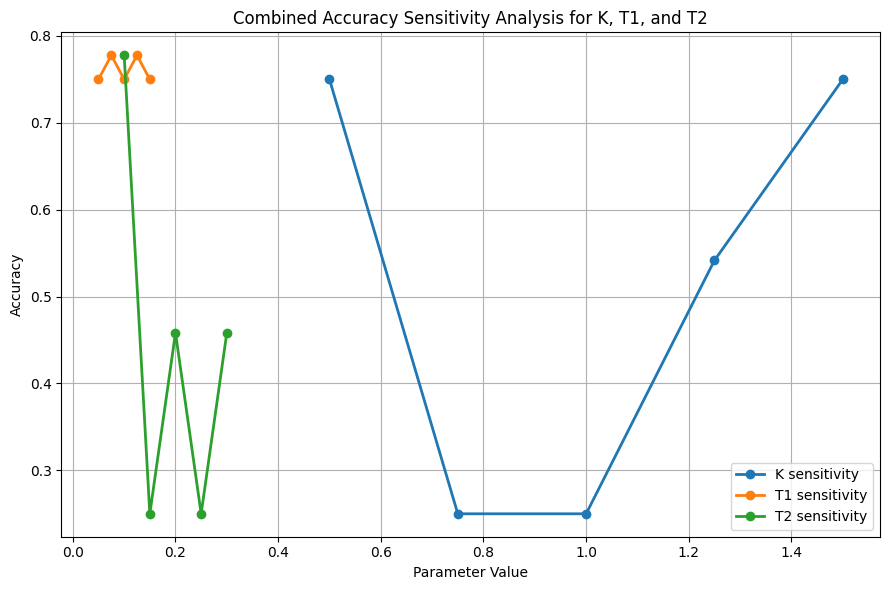

In [ ]:
# ============================================================
# Combined sensitivity plot: Accuracy only
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for parameter in ["K", "T1", "T2"]:

    temp_df = sensitivity_all_df[
        sensitivity_all_df["Parameter"] == parameter
    ].sort_values("Value")

    plt.plot(
        temp_df["Value"],
        temp_df["Accuracy"],
        marker="o",
        linewidth=2,
        label=f"{parameter} sensitivity"
    )

plt.xlabel("Parameter Value")
plt.ylabel("Accuracy")
plt.title("Combined Accuracy Sensitivity Analysis for K, T1, and T2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_accuracy_sensitivity_K_T1_T2.png", dpi=300)
plt.show()

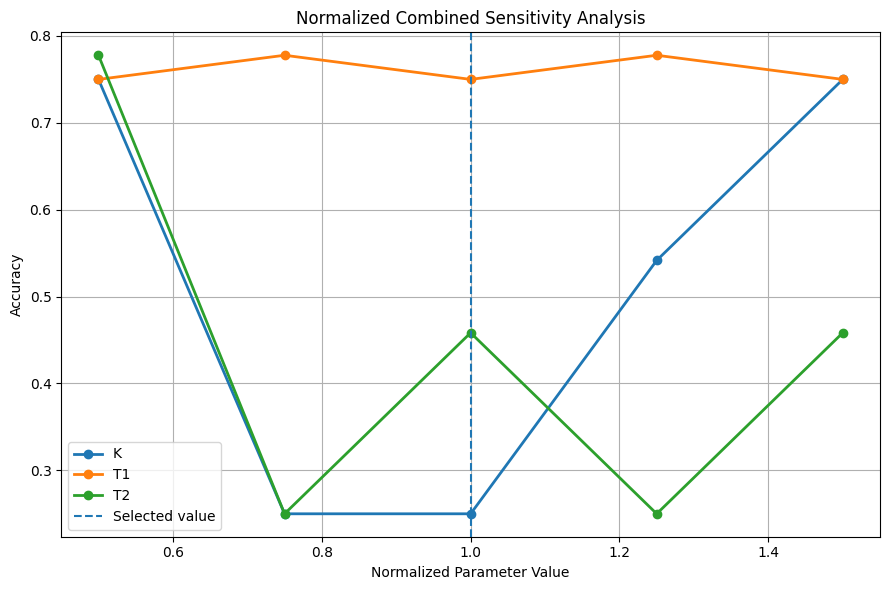

In [ ]:
# ============================================================
# Normalized combined sensitivity plot
# Best single-panel plot for manuscript
# ============================================================

import matplotlib.pyplot as plt

optimal_values = {
    "K": 1.0,
    "T1": 0.1,
    "T2": 0.2
}

plt.figure(figsize=(9, 6))

for parameter in ["K", "T1", "T2"]:

    temp_df = sensitivity_all_df[
        sensitivity_all_df["Parameter"] == parameter
    ].copy()

    temp_df = temp_df.sort_values("Value")

    temp_df["Normalized_Value"] = (
        temp_df["Value"] / optimal_values[parameter]
    )

    plt.plot(
        temp_df["Normalized_Value"],
        temp_df["Accuracy"],
        marker="o",
        linewidth=2,
        label=f"{parameter}"
    )

plt.axvline(
    x=1.0,
    linestyle="--",
    linewidth=1.5,
    label="Selected value"
)

plt.xlabel("Normalized Parameter Value")
plt.ylabel("Accuracy")
plt.title("Normalized Combined Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("normalized_combined_accuracy_sensitivity.png", dpi=300)
plt.show()

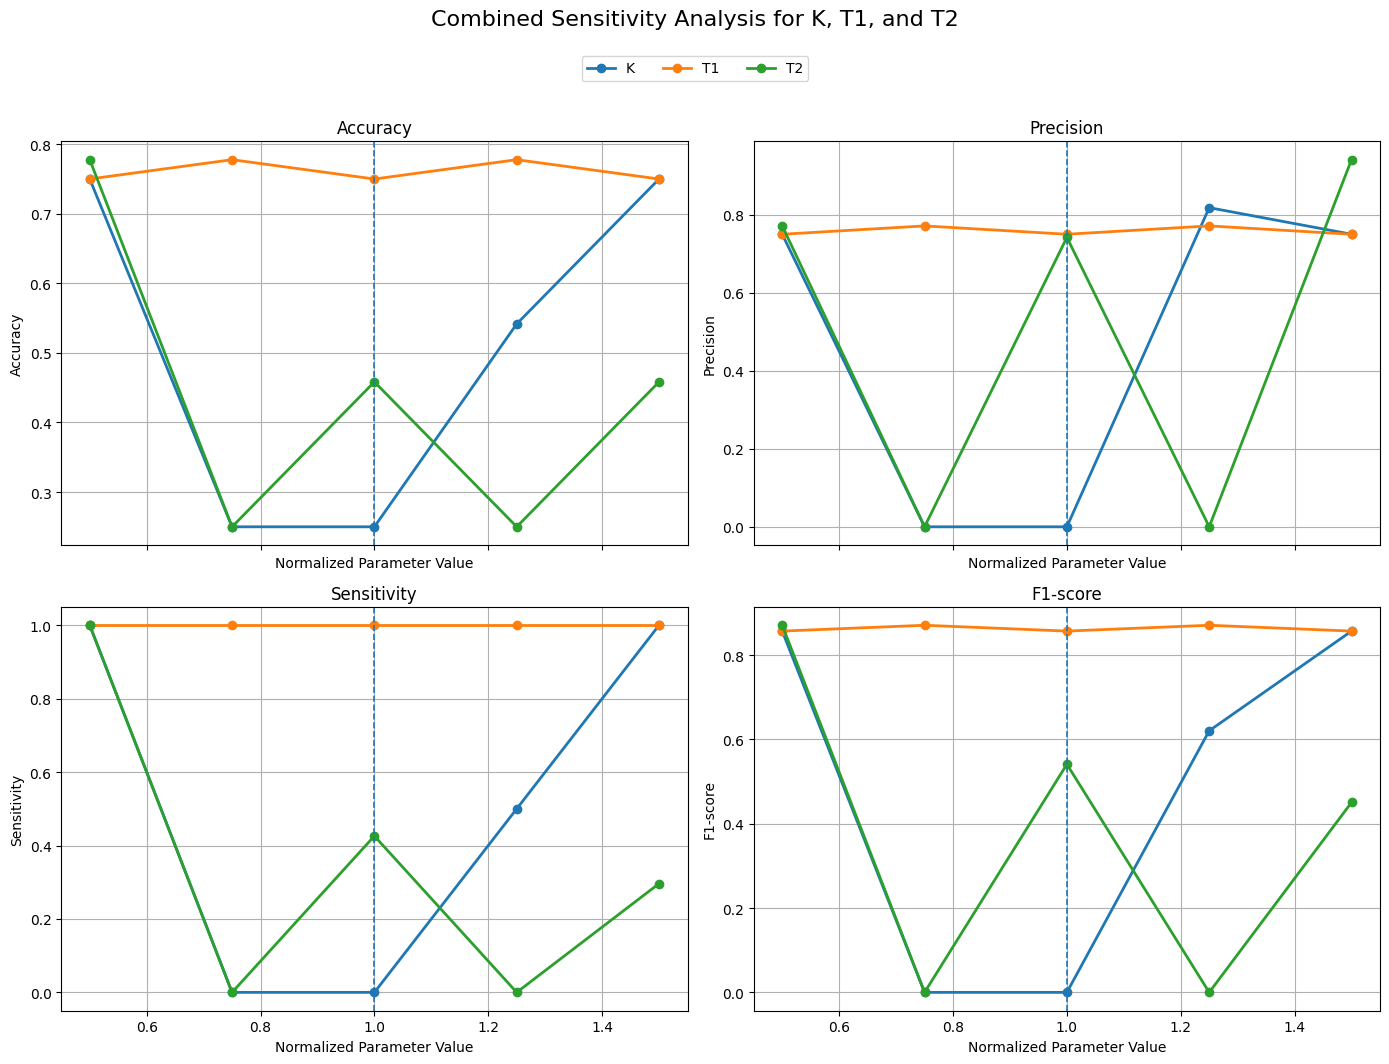

In [ ]:
# ============================================================
# Normalized combined sensitivity plot for all metrics
# ============================================================

import matplotlib.pyplot as plt

optimal_values = {
    "K": 1.0,
    "T1": 0.1,
    "T2": 0.2
}

metrics = {
    "Accuracy": "Accuracy",
    "Precision": "Precision",
    "Sensitivity": "Sensitivity",
    "F1_score": "F1-score"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

axes = axes.ravel()

for ax, (metric_col, metric_title) in zip(axes, metrics.items()):

    for parameter in ["K", "T1", "T2"]:

        temp_df = sensitivity_all_df[
            sensitivity_all_df["Parameter"] == parameter
        ].copy()

        temp_df = temp_df.sort_values("Value")

        temp_df["Normalized_Value"] = (
            temp_df["Value"] / optimal_values[parameter]
        )

        ax.plot(
            temp_df["Normalized_Value"],
            temp_df[metric_col],
            marker="o",
            linewidth=2,
            label=parameter
        )

    ax.axvline(
        x=1.0,
        linestyle="--",
        linewidth=1.2
    )

    ax.set_title(metric_title)
    ax.set_xlabel("Normalized Parameter Value")
    ax.set_ylabel(metric_title)
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle(
    "Combined Sensitivity Analysis for K, T1, and T2",
    y=1.06,
    fontsize=16
)

plt.tight_layout()
plt.savefig("normalized_combined_sensitivity_all_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Create y_true, y_prob, y_pred for test data
# ============================================================

import numpy as np

test_data.reset()

y_true = test_data.classes

y_prob = model.predict(test_data, verbose=1).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("Total test images:", len(y_true))
print("Total predictions:", len(y_pred))
print("First 10 true labels:", y_true[:10])
print("First 10 predicted labels:", y_pred[:10])
print("First 10 probabilities:", y_prob[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Total test images: 72
Total predictions: 72
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]
First 10 predicted labels: [0 0 1 1 1 1 1 1 1 1]
First 10 probabilities: [0.4467035  0.44528404 0.53210926 0.52338415 0.52296925 0.5191565
 0.518846   0.531974   0.5047824  0.50287306]
